# Netflix Movies and TV Shows - Data Cleaning

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (Kaggle, by Shivam Bansal)

**Goal:** Load the raw `netflix_titles.csv` file, understand *why* values are missing or malformed,
make deliberate column-by-column decisions about how to handle them, and export a cleaned CSV.

We deliberately avoid a blind `.dropna()` - instead each column gets its own reasoning.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Load the data

In [2]:
df = pd.read_csv('netflix_titles.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. First inspection

Before touching anything, look at the structure, data types, and summary statistics.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


`.describe()` on its own isn't very useful here since almost every column is text/object - but it confirms `release_year` is the only numeric column, and shows its range.

In [4]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
# object/string columns: describe() with include='object' shows unique counts and top values,
# which is more useful for this dataset than the numeric-only default
df.describe(include='object')

/tmp/ipykernel_620/1414257200.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


## 3. Missing values - the full picture

Instead of jumping straight to `dropna()`, look at *how much* is missing in each column and
*what kind* of column it is, since that changes the right decision.

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


**Reading the table:**
- `director` (~30% missing) and `cast` (~9% missing) - Netflix's own catalog metadata is simply
  incomplete for many titles (common for older titles, stand-up specials, documentaries with no
  credited "cast" in the traditional sense, etc.). This is *not* something we can impute - there's
  no way to guess who directed a movie. Dropping ~30% of rows would be far too destructive, so we
  keep the rows and mark these as explicitly unknown.
- `country` (~9% missing) - similarly not guessable from other columns, and country is often
  genuinely ambiguous for international co-productions. Same treatment: explicit "Unknown" flag
  rather than deletion or a fabricated mode-fill.
- `date_added` (10 rows, ~0.1%) - a negligible number of rows. Since this column matters for any
  time-series analysis (titles added per year/month) and we can't infer when Netflix uploaded a
  title, we drop these few rows rather than guess a date.
- `rating` (4 rows missing, plus a data-entry issue found below) - small enough to fill with the
  overall mode after fixing the data-entry issue.
- `duration` (3 rows missing) - turns out these are the *same* 3 rows where `rating` accidentally
  contains a duration value. This is a column-shift/data-entry bug, not a real missing value, and
  needs to be fixed by moving the value to the right column rather than treated as NaN.

### 3a. `director` - fill with an explicit placeholder

In [7]:
df['director'] = df['director'].fillna('Unknown')
df['director'].isna().sum()

np.int64(0)

### 3b. `cast` - fill with an explicit placeholder

In [8]:
df['cast'] = df['cast'].fillna('Unknown')
df['cast'].isna().sum()

np.int64(0)

### 3c. `country` - fill with an explicit placeholder

We avoid filling with the most common country (the US) - that would silently invent data for ~800+ titles and bias any "titles by country" analysis.

In [9]:
df['country'] = df['country'].fillna('Unknown')
df['country'].isna().sum()

np.int64(0)

### 3d. `rating` - fix a data-entry bug, then fill the true gaps

First, check what's actually in the `rating` column - it should only ever hold values like
`TV-MA`, `PG-13`, `R`, etc.

In [10]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Three rows have a duration value (`'74 min'`, `'84 min'`, `'66 min'`) sitting in the `rating` column, with `duration` itself blank for those same rows - a classic column-shift error, not a genuine missing rating. Fix it by moving the value across before doing anything else.

In [11]:
shifted = df['rating'].isin(['74 min', '84 min', '66 min'])
print(f"Rows affected: {shifted.sum()}")
df.loc[shifted, ['show_id', 'title', 'rating', 'duration']]

Rows affected: 3


,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [12]:
# Move the misplaced duration value into the duration column, then blank out the rating
# (it was never actually known for these rows)
df.loc[shifted, 'duration'] = df.loc[shifted, 'rating']
df.loc[shifted, 'rating'] = np.nan

df.loc[shifted, ['show_id', 'title', 'rating', 'duration']]

,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,NaN,74 min
5794,s5795,Louis C.K.: Hilarious,NaN,84 min
5813,s5814,Louis C.K.: Live at the Comedy Store,NaN,66 min


Now the remaining `rating` gaps (4 originally + the 3 we just cleared out = 7) are genuine unknowns. With so few, filling with the column mode is a reasonable, low-risk choice.

In [13]:
print(f"Missing ratings now: {df['rating'].isna().sum()}")
rating_mode = df['rating'].mode()[0]
print(f"Mode rating: {rating_mode}")
df['rating'] = df['rating'].fillna(rating_mode)
df['rating'].isna().sum()

Missing ratings now: 7
Mode rating: TV-MA


np.int64(0)

### 3e. `date_added` - drop the handful of rows we can't infer

Only 10 rows are missing this. That's small enough that dropping them costs us almost nothing, and there's no reliable way to infer *when* a title was added to the catalog.

In [14]:
before = len(df)
df = df.dropna(subset=['date_added'])
print(f"Dropped {before - len(df)} rows. New shape: {df.shape}")

Dropped 10 rows. New shape: (8797, 12)


### 3f. `duration` - confirm it's now fully populated

In [15]:
df['duration'].isna().sum()

np.int64(0)

## 4. Fixing mixed-type columns

`duration` mixes two different things depending on `type`:
- Movies: `"90 min"` - a runtime in minutes
- TV Shows: `"1 Season"` / `"2 Seasons"` - a season count

Storing both as one string column means you can't do numeric analysis on either. Split it into
a numeric `duration_value` and a `duration_unit`, driven by `type`.

In [16]:
df[['duration_value', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_value'] = pd.to_numeric(df['duration_value'])

# Sanity check: unit should line up with type (min -> Movie, Season/Seasons -> TV Show)
pd.crosstab(df['type'], df['duration_unit'])

duration_unit,Season,Seasons,min
type,,,
Movie,0,0,6131
TV Show,1793,873,0


In [17]:
df[['type', 'duration', 'duration_value', 'duration_unit']].sample(8, random_state=1)

,type,duration,duration_value,duration_unit
7292,Movie,78 min,78,min
5855,TV Show,2 Seasons,2,Seasons
7030,Movie,85 min,85,min
3458,TV Show,1 Season,1,Season
7939,Movie,133 min,133,min
5240,Movie,107 min,107,min
1936,Movie,80 min,80,min
331,TV Show,1 Season,1,Season


## 5. Parsing dates

`date_added` is a string like `"September 25, 2021"`, and `release_year` is already a clean int
(no work needed there). Convert `date_added` into a real `datetime64` so it can be resampled,
sorted, and filtered properly.

In [18]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')
df['date_added'].dtype

dtype('<M8[us]')

In [19]:
# Now that it's a real datetime, derive a couple of convenience columns often needed downstream
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df[['title', 'date_added', 'year_added', 'month_added']].head()

,title,date_added,year_added,month_added
0,Dick Johnson Is Dead,2021-09-25,2021,September
1,Blood & Water,2021-09-24,2021,September
2,Ganglands,2021-09-24,2021,September
3,Jailbirds New Orleans,2021-09-24,2021,September
4,Kota Factory,2021-09-24,2021,September


## 6. Final check

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8797 non-null   str           
 1   type            8797 non-null   str           
 2   title           8797 non-null   str           
 3   director        8797 non-null   str           
 4   cast            8797 non-null   str           
 5   country         8797 non-null   str           
 6   date_added      8797 non-null   datetime64[us]
 7   release_year    8797 non-null   int64         
 8   rating          8797 non-null   str           
 9   duration        8797 non-null   str           
 10  listed_in       8797 non-null   str           
 11  description     8797 non-null   str           
 12  duration_value  8797 non-null   int64         
 13  duration_unit   8797 non-null   str           
 14  year_added      8797 non-null   int32         
 15  month_added     8797

In [21]:
print("Remaining nulls per column:")
df.isna().sum()

Remaining nulls per column:


show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
duration_value    0
duration_unit     0
year_added        0
month_added       0
dtype: int64

Every column is now either fully populated, or intentionally marked `'Unknown'` where the original data genuinely didn't know the answer - which is different from a silent, misleading `NaN`.

## 8. Visualizing the cleaned data

A few quick plots to sanity-check the cleaning and pull out some obvious patterns.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

### Movies vs TV Shows

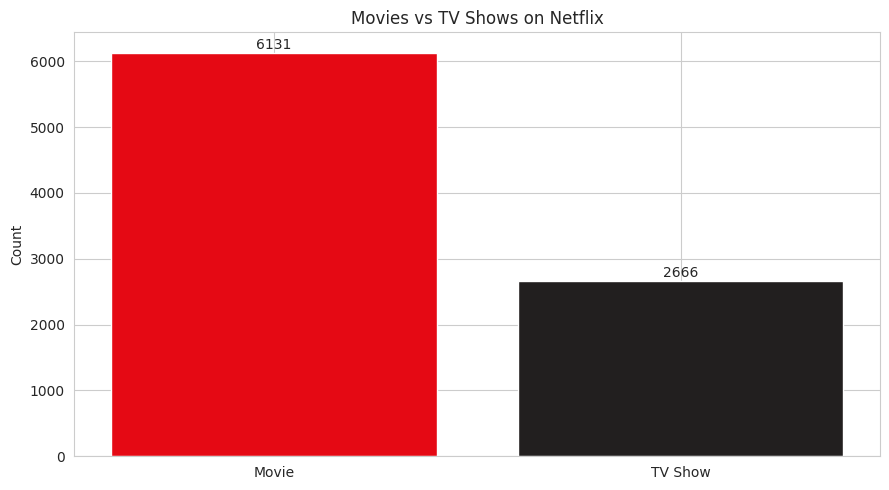

In [23]:
type_counts = df['type'].value_counts()
plt.figure()
plt.bar(type_counts.index, type_counts.values, color=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Count')
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

### Titles added per year

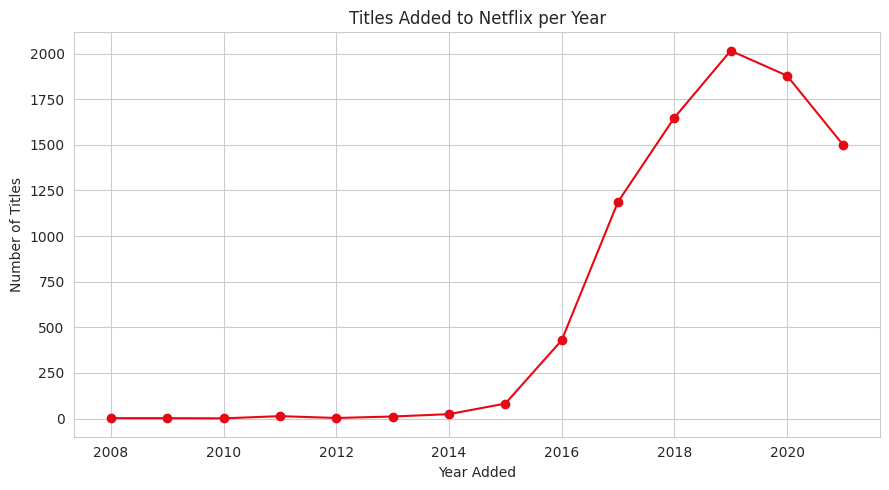

In [24]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure()
plt.plot(yearly.index, yearly.values, marker='o', color='#E50914')
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

### Top 10 content ratings

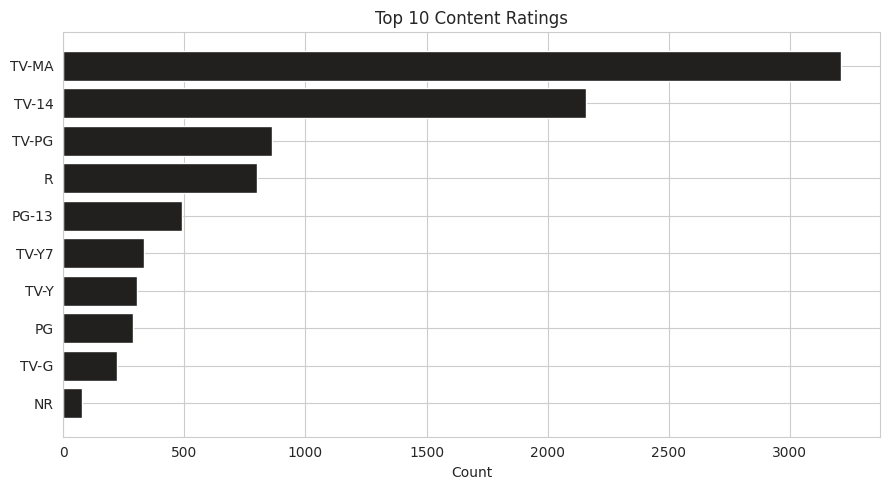

In [25]:
top_ratings = df['rating'].value_counts().head(10)
plt.figure()
plt.barh(top_ratings.index[::-1], top_ratings.values[::-1], color='#221f1f')
plt.title('Top 10 Content Ratings')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### Movie duration distribution (minutes)

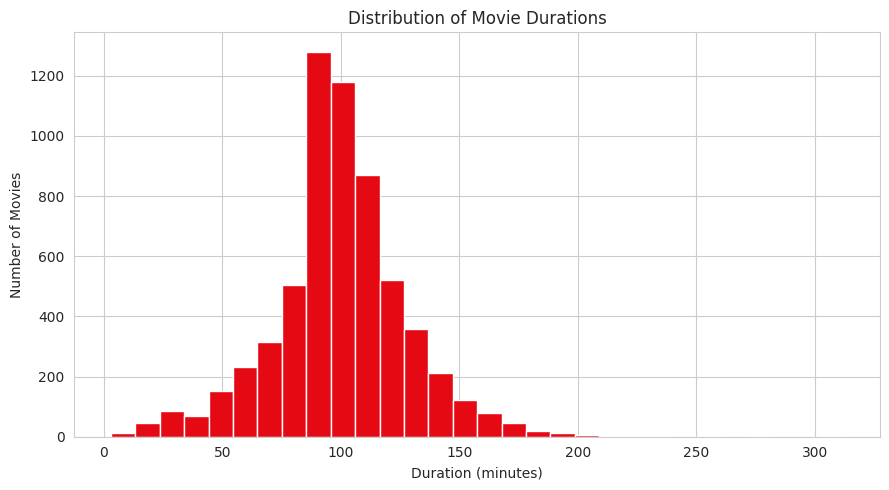

In [26]:
movie_durations = df.loc[df['type'] == 'Movie', 'duration_value']
plt.figure()
plt.hist(movie_durations, bins=30, color='#E50914', edgecolor='white')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

### Top 10 countries by title count

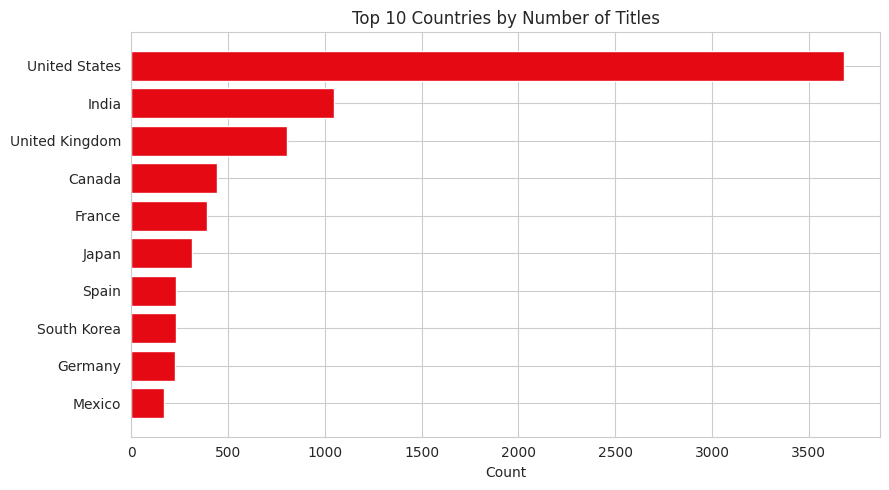

In [27]:
top_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode().value_counts().head(10)
plt.figure()
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

## 7. Export the cleaned dataset

In [28]:
df.to_csv('netflix_titles_cleaned.csv', index=False)
print(f"Saved netflix_titles_cleaned.csv - {df.shape[0]} rows, {df.shape[1]} columns")

Saved netflix_titles_cleaned.csv - 8797 rows, 16 columns


## Summary of decisions

| Column | Issue | Decision | Reasoning |
|---|---|---|---|
| `director` | ~30% missing | Filled with `'Unknown'` | Not guessable; too much data to drop |
| `cast` | ~9% missing | Filled with `'Unknown'` | Not guessable; too much data to drop |
| `country` | ~9% missing | Filled with `'Unknown'` | Not guessable; mode-fill would bias country analysis |
| `date_added` | 10 rows missing | Dropped rows | Trivial row count, no way to infer the date |
| `rating` | 3 rows had a duration value in them; 4 rows genuinely blank | Moved shifted values to `duration`, filled remaining 7 with the mode | Fixes a data-entry bug distinct from real missingness |
| `duration` | Mixed units (minutes vs. seasons) in one string column | Split into `duration_value` (numeric) + `duration_unit` | Enables numeric analysis, keeps units explicit |
| `date_added` | Stored as text | Parsed to `datetime64`, added `year_added` / `month_added` | Enables time-series analysis |


## 8. Visualizations

A few quick charts to sanity-check the cleaned data and surface some patterns.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

### Movies vs TV Shows

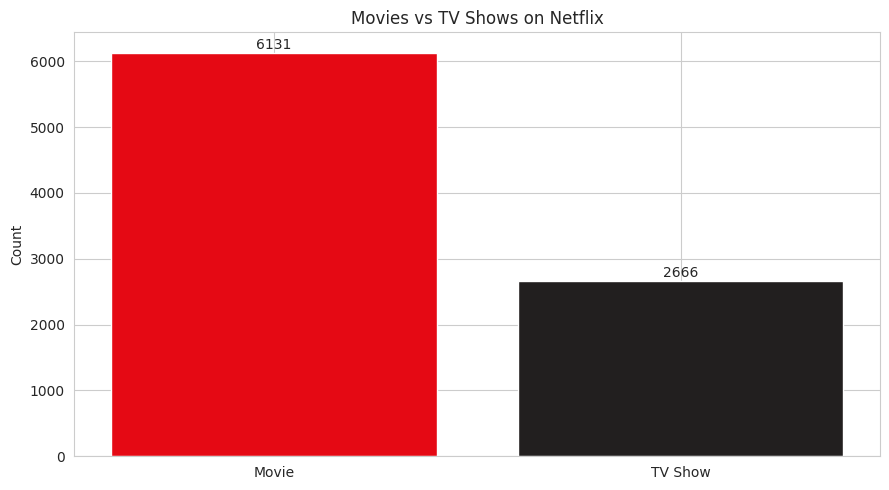

In [30]:
type_counts = df['type'].value_counts()
plt.figure()
plt.bar(type_counts.index, type_counts.values, color=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Count')
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig('viz_type_counts.png', dpi=120)
plt.show()

### Titles added per year

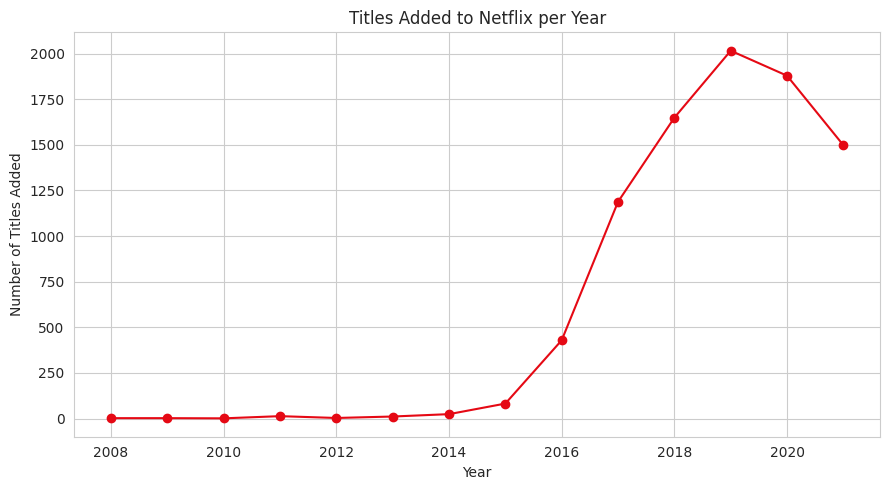

In [31]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure()
plt.plot(yearly.index, yearly.values, marker='o', color='#E50914')
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.savefig('viz_titles_per_year.png', dpi=120)
plt.show()

### Top 10 countries by number of titles

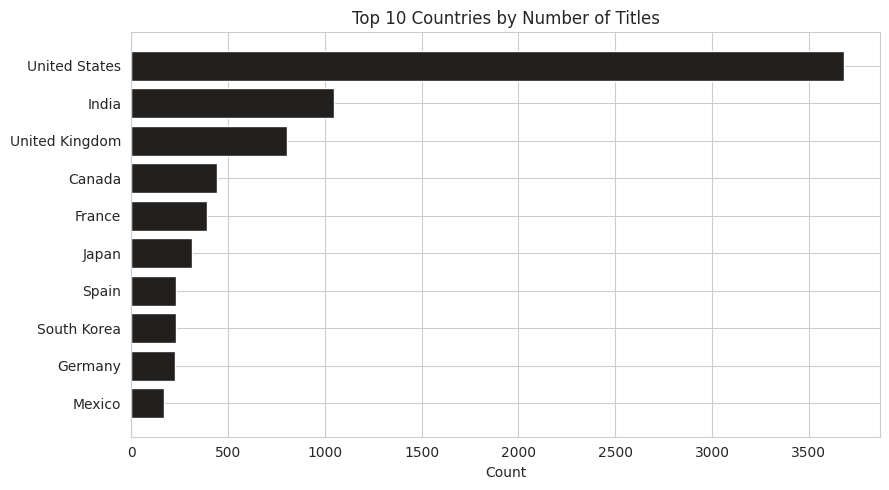

In [32]:
top_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode().value_counts().head(10)
plt.figure()
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#221f1f')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('viz_top_countries.png', dpi=120)
plt.show()

### Distribution of movie runtimes

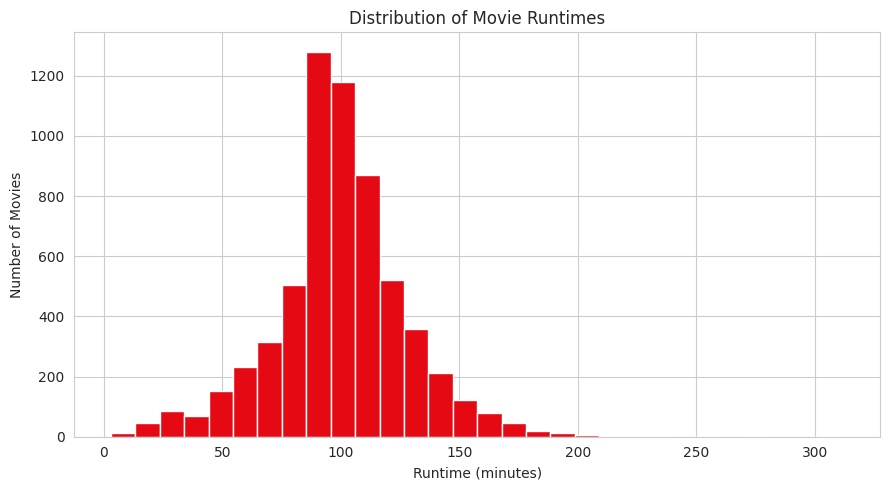

In [33]:
movie_durations = df[df['type'] == 'Movie']['duration_value']
plt.figure()
plt.hist(movie_durations, bins=30, color='#E50914', edgecolor='white')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('viz_movie_runtime_dist.png', dpi=120)
plt.show()

### Content ratings breakdown

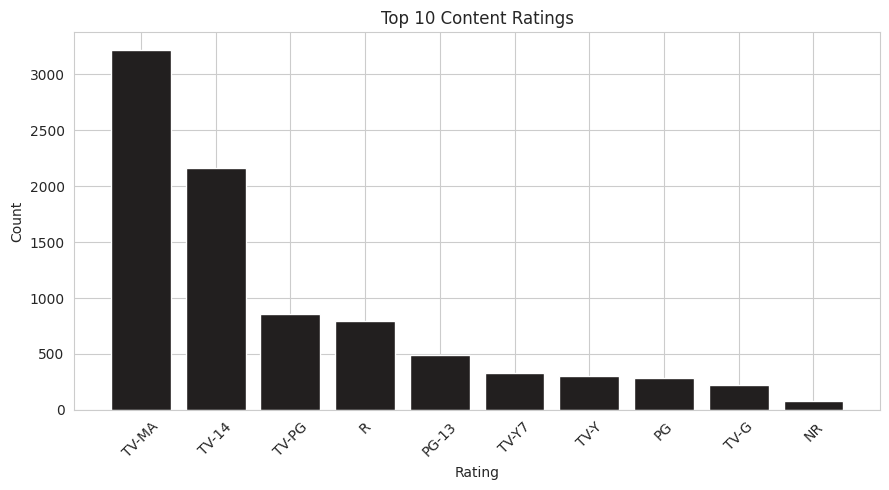

In [34]:
rating_counts = df['rating'].value_counts().head(10)
plt.figure()
plt.bar(rating_counts.index, rating_counts.values, color='#221f1f')
plt.title('Top 10 Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz_ratings.png', dpi=120)
plt.show()